<a href="https://colab.research.google.com/github/SaiLinHtet-KiRA/Big-Data-Analytics/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **2. Environment Setup**

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# **3. Load and Inspect the Raw Data**

### **Step 3.1 — Load the CSV**

In [4]:
df = pd.read_csv("https://raw.githubusercontent.com/SaiLinHtet-KiRA/Big-Data-Analytics/refs/heads/main/orders.csv")

print("Shape:", df.shape)
display(df.head(10))

Shape: (37, 9)


,order_id,customer_id,age,city,category,quantity,unit_price,order_date,payment_method
0,A1001,C001,25.0,bangkok,Electronics,1,25900,01/09/2026,Credit Card
1,A1002,C002,31.0,BANGKOK,electronics,2,890,2026-09-02,PromptPay
2,A1002,C002,31.0,BANGKOK,electronics,2,890,2026-09-02,PromptPay
3,A1003,C003,NaN,Chiang mai,Fashion,1,1290,3 Sep 2026,Credit Card
4,A1004,C004,999.0,Bkk,Home,1,3500,04-09-2026,Cash on Delivery
5,A1005,C005,22.0,Phuket,Beauty,3,450,05/09/2026,PromptPay
6,A1006,C006,28.0,phuket,fashion,-1,1790,2026/09/06,Credit Card
7,A1007,C007,35.0,Chiang Mai,Home,2,NaN,07/09/2026,Credit Card
8,A1008,C008,41.0,Bangkok,Electronics,1,45900,2026-09-08,Bank Transfer
9,A1009,C009,19.0,BANGKOK,Beauty,2,650,09 Sep 2026,PromptPay


## **Step 3.2 — Inspect structure and quality**

In [5]:
df.info()

print("\nMissing values by column:")
print(df.isna().sum())

print("\nExact duplicate rows:", df.duplicated().sum())

print("\nUnique city labels:")
print(df["city"].value_counts(dropna=False))

print("\nUnique category labels:")
print(df["category"].value_counts(dropna=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        37 non-null     object 
 1   customer_id     37 non-null     object 
 2   age             34 non-null     float64
 3   city            36 non-null     object 
 4   category        37 non-null     object 
 5   quantity        37 non-null     int64  
 6   unit_price      36 non-null     object 
 7   order_date      37 non-null     object 
 8   payment_method  36 non-null     object 
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ KB

Missing values by column:
order_id          0
customer_id       0
age               3
city              1
category          0
quantity          0
unit_price        1
order_date        0
payment_method    1
dtype: int64

Exact duplicate rows: 1

Unique city labels:
city
Bangkok       9
Chiang Mai    5
Phuket        4
Khon Kaen     3
Pattay

# **4. Missing Values**

## **Step 4.1 — Build a missing-value report**

In [6]:
missing_count = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(1)

missing_report = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_pct
})

print(missing_report)

                missing_count  missing_percent
order_id                    0              0.0
customer_id                 0              0.0
age                         3              8.1
city                        1              2.7
category                    0              0.0
quantity                    0              0.0
unit_price                  1              2.7
order_date                  0              0.0
payment_method              1              2.7


## **Step 4.2 — Convert invalid values to missing values**

In [7]:
# Convert to numeric first so invalid text becomes NaN
df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")
df["unit_price"] = pd.to_numeric(df["unit_price"], errors="coerce")

# Apply simple business rules
df.loc[~df["age"].between(15, 100), "age"] = pd.NA
df.loc[df["quantity"] <= 0, "quantity"] = pd.NA
df.loc[df["unit_price"] <= 0, "unit_price"] = pd.NA

print(df[["age", "quantity", "unit_price"]].isna().sum())

age           4
quantity      1
unit_price    3
dtype: int64


## **Step 4.3 — Impute numerical missing values**

In [8]:
# Age: robust median imputation
df["age"] = df["age"].fillna(df["age"].median())

# Unit price: category median, then overall median
category_price = df.groupby("category")["unit_price"].transform("median")
df["unit_price"] = df["unit_price"].fillna(category_price)
df["unit_price"] = df["unit_price"].fillna(df["unit_price"].median())

# Quantity: category median for this teaching dataset
category_qty = df.groupby("category")["quantity"].transform("median")
df["quantity"] = df["quantity"].fillna(category_qty)
df["quantity"] = df["quantity"].fillna(df["quantity"].median())


# **5. Duplicate Records and Inconsistent Labels**

## **Step 5.1 — Inspect duplicates before removing them**

In [9]:
# Exact duplicate rows
exact_dups = df[df.duplicated(keep=False)]
print(exact_dups)

# Duplicate business key: order_id
order_dups = df[df.duplicated(subset=["order_id"], keep=False)]
print(order_dups.sort_values("order_id"))

  order_id customer_id   age     city       category  quantity  unit_price  order_date payment_method
1    A1002        C002  31.0  BANGKOK   electronics        2.0       890.0  2026-09-02      PromptPay
2    A1002        C002  31.0  BANGKOK   electronics        2.0       890.0  2026-09-02      PromptPay
   order_id customer_id   age     city       category  quantity  unit_price  order_date payment_method
1     A1002        C002  31.0  BANGKOK   electronics        2.0       890.0  2026-09-02      PromptPay
2     A1002        C002  31.0  BANGKOK   electronics        2.0       890.0  2026-09-02      PromptPay
12    A1012        C012  33.0  Bangkok           Home       1.0      7800.0  12/09/2026  Bank Transfer
13    A1012        C012  33.0  Bangkok           Home       1.0      7500.0  12/09/2026  Bank Transfer


## **Step 5.2 — Remove verified duplicates**

In [10]:
# Remove exact duplicates first
df = df.drop_duplicates().copy()

# Then resolve duplicate order IDs using the lab assumption
df = df.drop_duplicates(subset=["order_id"], keep="first").copy()

print("Shape after deduplication:", df.shape)

Shape after deduplication: (35, 9)


## **Step 5.3 — Normalize text labels**

In [11]:
df["city"] = (
    df["city"]
      .astype("string")
      .str.strip()
      .str.replace(r"\s+", " ", regex=True)
      .str.title()
      .replace({"Bkk": "Bangkok"})
)

df["category"] = (
    df["category"]
      .astype("string")
      .str.strip()
      .str.title()
)

df["payment_method"] = (
    df["payment_method"]
      .astype("string")
      .str.strip()
      .replace({"": pd.NA})
            .fillna("Unknown")
)

print(sorted(df["city"].dropna().unique()))
print(sorted(df["category"].dropna().unique()))

['Bangkok', 'Chiang Mai', 'Khon Kaen', 'Pattaya', 'Phuket']
['Beauty', 'Electronics', 'Fashion', 'Home', 'Sports']


# **6. Data Transformation and Date Parsing**

## **Step 6.1 — Convert dates and data types**

In [12]:
# Parse mixed date formats; impossible dates become NaT
df["order_date"] = pd.to_datetime(
    df["order_date"],
    errors="coerce",
    dayfirst=True,
    format="mixed"
)

# Optional compact integer type for age after imputation
df["age"] = df["age"].round().astype("Int64")

# Category dtype can reduce memory for repeated labels
df["category"] = df["category"].astype("category")

print(df.dtypes)
print("Invalid dates:", df["order_date"].isna().sum())

order_id                  object
customer_id               object
age                        Int64
city              string[python]
category                category
quantity                 float64
unit_price               float64
order_date        datetime64[ns]
payment_method    string[python]
dtype: object
Invalid dates: 1


# **7. Validate the Cleaned Data**

## **Step 7.1 — Run validation checks**

In [13]:
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isna().sum())

print("\nAge range:", df["age"].min(), "to", df["age"].max())
print("Quantity min:", df["quantity"].min())
print("Unit price min:", df["unit_price"].min())

print("\nCities:", sorted(df["city"].dropna().unique()))
print("Categories:", list(df["category"].cat.categories))

Shape: (35, 9)

Missing values:
order_id          0
customer_id       0
age               0
city              1
category          0
quantity          0
unit_price        0
order_date        1
payment_method    0
dtype: int64

Age range: 18 to 55
Quantity min: 1.0
Unit price min: 390.0

Cities: ['Bangkok', 'Chiang Mai', 'Khon Kaen', 'Pattaya', 'Phuket']
Categories: ['Beauty', 'Electronics', 'Fashion', 'Home', 'Sports']


# **8. Feature Engineering**

## **Step 8.1 — Create analytical features**

In [14]:
# Transaction value
df["total_value"] = df["quantity"] * df["unit_price"]

# Time features
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["weekday"] = df["order_date"].dt.day_name()
df["is_weekend"] = df["order_date"].dt.dayofweek >= 5

display(df[[
    "order_id", "quantity", "unit_price", "total_value",
    "order_date", "weekday", "is_weekend"
]].head())

,order_id,quantity,unit_price,total_value,order_date,weekday,is_weekend
0,A1001,1.0,25900.0,25900.0,2026-09-01,Tuesday,False
1,A1002,2.0,890.0,1780.0,2026-09-02,Wednesday,False
3,A1003,1.0,1290.0,1290.0,2026-09-03,Thursday,False
4,A1004,1.0,3500.0,3500.0,2026-09-04,Friday,False
5,A1005,3.0,450.0,1350.0,2026-09-05,Saturday,True


# **9. Data Aggregation with groupby() and agg()**

## **Step 9.1 — Summarize revenue by city**

In [15]:
city_sales = (
    df.groupby("city", as_index=False)
      .agg(
          revenue=("total_value", "sum"),
          orders=("order_id", "nunique"),
          customers=("customer_id", "nunique")
      )
)

city_sales["avg_order_value"] = (
    city_sales["revenue"] / city_sales["orders"]
)

city_sales = city_sales.sort_values("revenue", ascending=False)
display(city_sales)

,city,revenue,orders,customers,avg_order_value
0,Bangkok,168020.0,14,14,12001.428571
1,Chiang Mai,47450.0,7,7,6778.571429
3,Pattaya,26890.0,4,4,6722.500000
2,Khon Kaen,23200.0,4,4,5800.000000
4,Phuket,11300.0,5,5,2260.000000


## **Step 9.2 — Multiple aggregations by category**

In [16]:
category_summary = (
    df.groupby("category", observed=True)
      .agg(
          revenue=("total_value", "sum"),
          avg_value=("total_value", "mean"),
          median_value=("total_value", "median"),
          customers=("customer_id", "nunique"),
                    orders=("order_id", "nunique")
      )
      .sort_values("revenue", ascending=False)
)

display(category_summary)

,revenue,avg_value,median_value,customers,orders
category,,,,,
Electronics,180680.0,22585.000000,22900.0,8,8
Home,52100.0,6512.500000,5800.0,8,8
Sports,23390.0,3341.428571,3200.0,7,7
Fashion,13910.0,2318.333333,2440.0,6,6
Beauty,9560.0,1593.333333,1455.0,6,6


## **Step 9.3 — Create a city × category pivot table**

In [17]:
pivot = pd.pivot_table(
    df,
    index="city",
    columns="category",
    values="total_value",
    aggfunc="sum",
    fill_value=0,
    observed=True
)

display(pivot)

category,Beauty,Electronics,Fashion,Home,Sports
city,,,,,
Bangkok,5060.0,132380.0,2980.0,20500.0,7100.0
Chiang Mai,2160.0,19900.0,3390.0,22000.0,0.0
Khon Kaen,0.0,12500.0,0.0,5200.0,5500.0
Pattaya,990.0,15900.0,0.0,4400.0,5600.0
Phuket,1350.0,0.0,4760.0,0.0,5190.0


# **10. Exploratory Data Analysis (EDA)**

## **10.1 Univariate Analysis**

In [18]:
print(df["total_value"].describe())

print("\nOrders by city:")
print(df["city"].value_counts())

print("\nCategory proportions:")
print(df["category"].value_counts(normalize=True).round(3))

count       35.000000
mean      7989.714286
std      10321.713972
min        990.000000
25%       2130.000000
50%       3500.000000
75%       8500.000000
max      45900.000000
Name: total_value, dtype: float64

Orders by city:
city
Bangkok       14
Chiang Mai     7
Phuket         5
Khon Kaen      4
Pattaya        4
Name: count, dtype: Int64

Category proportions:
category
Electronics    0.229
Home           0.229
Sports         0.200
Beauty         0.171
Fashion        0.171
Name: proportion, dtype: float64


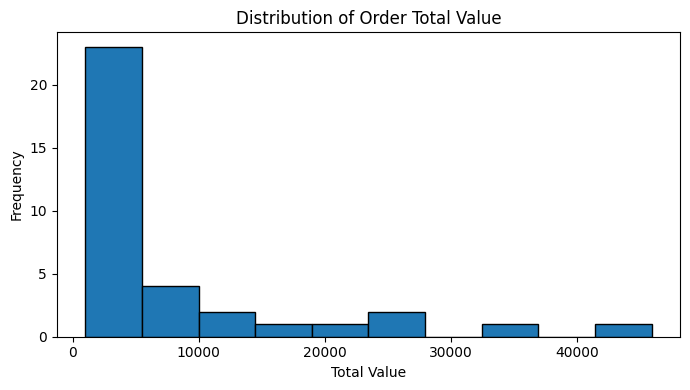

In [19]:
plt.figure(figsize=(7, 4))
plt.hist(df["total_value"].dropna(), bins=10, edgecolor="black")
plt.title("Distribution of Order Total Value")
plt.xlabel("Total Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## **10.2 Bivariate Analysis**

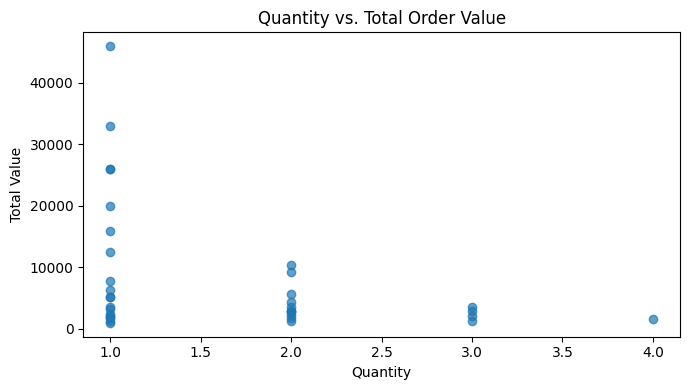

In [20]:
plt.figure(figsize=(7, 4))
plt.scatter(df["quantity"], df["total_value"], alpha=0.7)
plt.title("Quantity vs. Total Order Value")
plt.xlabel("Quantity")
plt.ylabel("Total Value")
plt.tight_layout()
plt.show()

<Figure size 700x400 with 0 Axes>

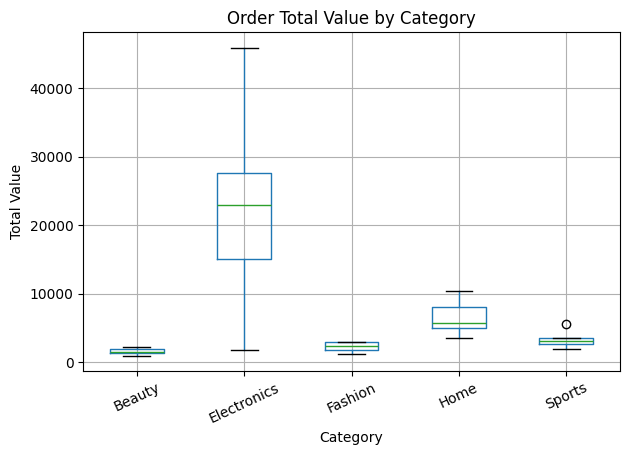

In [21]:
plt.figure(figsize=(7, 4))
df.boxplot(column="total_value", by="category", rot=25)
plt.title("Order Total Value by Category")
plt.suptitle("")
plt.xlabel("Category")
plt.ylabel("Total Value")
plt.tight_layout()
plt.show()

## **10.3 Correlation**

In [22]:
numeric_cols = ["age", "quantity", "unit_price", "total_value"]
correlation = df[numeric_cols].corr(numeric_only=True).round(2)
print(correlation)

              age  quantity  unit_price  total_value
age          1.00     -0.18        0.05         0.07
quantity    -0.18      1.00       -0.43        -0.37
unit_price   0.05     -0.43        1.00         0.99
total_value  0.07     -0.37        0.99         1.00


## **10.4 Revenue by City**

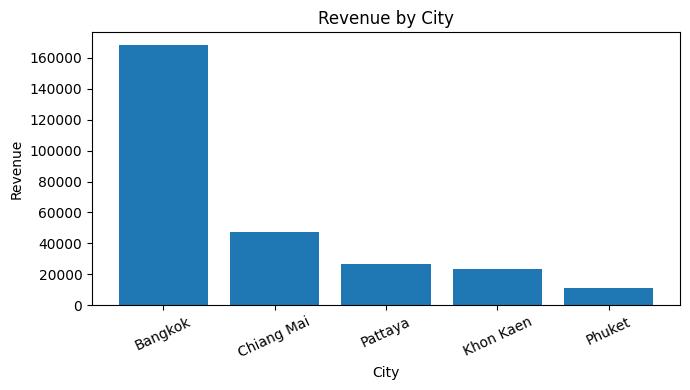

In [23]:
plt.figure(figsize=(7, 4))
plt.bar(city_sales["city"], city_sales["revenue"])
plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# **11. Save the Cleaned Data and Summaries**

In [24]:
df.to_csv(
    "orders_week3_cleaned.csv",
    index=False,
    encoding="utf-8-sig"
)

city_sales.to_csv(
    "week3_city_sales.csv",
    index=False,
    encoding="utf-8-sig"
)

category_summary.to_csv(
    "week3_category_summary.csv",
    encoding="utf-8-sig"
)

print("Files saved successfully.")

Files saved successfully.
